## 실습: 타이타닉 데이터 분석 (Numpy + Pandas + Matplotlib)
----
* 2-2(Numpy), 2-3(Pandas), 2-4(Matplotlib)에서 배운 내용을 **실제 데이터셋**에 적용해보는 실습
* 데이터셋: **타이타닉(Titanic)** 승객 데이터 (891명)
    - 1912년 타이타닉호 침몰 사고 승객들의 생존 여부와 정보
    - 데이터 분석 입문에서 가장 많이 사용되는 대표 데이터셋
* 진행 순서
    1. 데이터 불러오기
    2. 데이터 살펴보기 (Pandas 조회)
    3. 새로운 열 만들기 / 정렬하기
    4. 그룹별 집계
    5. Numpy로 통계 계산하기
    6. Matplotlib으로 시각화하기
    7. 종합 연습 문제

> 각 소단원 끝의 **[연습]** 셀은 직접 코드를 작성하는 부분입니다.
>
> 결측치 처리, 범주형 데이터 인코딩, 스케일 조정 등 **데이터 전처리**는 이 실습에서 다루지 않고 3-3에서 배웁니다.

In [1]:
## 패키지 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   # 데이터셋을 불러오기 위해서만 사용

### 1) 데이터 불러오기

* ```seaborn``` 패키지에 내장된 타이타닉 데이터셋을 ```pandas.DataFrame```으로 불러옴
* 각 열(column)의 의미

| 열 이름 | 의미 |
|---|---|
| survived | 생존 여부 (0 = 사망, 1 = 생존) |
| pclass | 객실 등급 (1, 2, 3등석) |
| sex | 성별 |
| age | 나이 |
| sibsp | 함께 탑승한 형제/배우자 수 |
| parch | 함께 탑승한 부모/자녀 수 |
| fare | 운임(요금) |
| embarked | 탑승 항구 (C = Cherbourg, Q = Queenstown, S = Southampton) |
| class | 객실 등급 (문자) |
| who | man / woman / child |
| adult_male | 성인 남성 여부 |
| deck | 객실 데크 (A~G) |
| embark_town | 탑승 도시 |
| alive | 생존 여부 (문자) |
| alone | 혼자 탑승 여부 |

In [2]:
df = sns.load_dataset('titanic')
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### 2) 데이터 살펴보기

* 분석을 시작하기 전에 데이터가 어떤 모양인지 확인하는 단계
* ```head()```, ```tail()```, ```shape```, ```info()```, ```describe()``` 등을 사용

In [ ]:
# 앞부분 5개 행 조회
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# 뒷부분 3개 행 조회
df.tail(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [ ]:
# 크기 (행, 열) -> numpy의 shape와 동일한 개념
print('shape :', df.shape)
print('행의 수 :', len(df))
print('열의 수 :', len(df.columns))

shape : (891, 15)
행의 수 : 891
열의 수 : 15


In [ ]:
# 열 이름, 인덱스, 값
print(df.columns) # 열 이름
print(df.index) 
print(type(df.values), df.values.shape)   # 값 부분은 numpy 배열

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
RangeIndex(start=0, stop=891, step=1)
<class 'numpy.ndarray'> (891, 15)


In [7]:
# 각 열의 자료형과 비어 있지 않은 값(Non-Null)의 개수
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


* ```info()``` 결과를 보면 전체 891행인데 ```age```는 714개, ```deck```은 203개만 값이 있음
    - 나머지는 값이 비어 있는 결측치(```NaN```)
    - 결측치를 어떻게 처리하는지는 **3-3 데이터 전처리**에서 배움
    - 이 실습에서는 나이 계산이 필요할 때 ```dropna()```로 비어 있는 값을 **제외하고** 사용

In [8]:
# 나이 열에서 비어 있는 값을 제외한 Series
age = df['age'].dropna()
print('전체 행 수 :', len(df['age']))
print('나이가 있는 행 수 :', len(age))

전체 행 수 : 891
나이가 있는 행 수 : 714


In [9]:
# 숫자형 열의 기초 통계량 (개수, 평균, 표준편차, 최소, 사분위수, 최대)
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### 열(column) 선택하기
* ```df['열이름']``` : 하나의 열 -> ```Series```
* ```df[['열이름1', '열이름2']]``` : 여러 열 -> ```DataFrame```

In [10]:
# 하나의 열 선택 -> Series
fares = df['fare']
print(type(fares))
print(fares.head())

<class 'pandas.core.series.Series'>
0     7.2500
1    71.2833
2     7.9250
3    53.1000
4     8.0500
Name: fare, dtype: float64


In [11]:
# 여러 열 선택 -> DataFrame
sub = df[['survived', 'pclass', 'sex', 'age', 'fare']]
print(type(sub))
sub.head()

<class 'pandas.core.frame.DataFrame'>


,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


#### 행(row) 선택하기
* ```df.loc[인덱스]``` : 인덱스 **이름**으로 선택
* ```df.iloc[번호]``` : **순서(정수 위치)**로 선택 -> numpy 인덱싱/슬라이싱과 같은 방식

In [12]:
# 0번 행 하나 선택
print(df.loc[0])

survived                 0
pclass                   3
sex                   male
age                   22.0
sibsp                    1
parch                    0
fare                  7.25
embarked                 S
class                Third
who                    man
adult_male            True
deck                   NaN
embark_town    Southampton
alive                   no
alone                False
Name: 0, dtype: object


In [13]:
# iloc: numpy처럼 [행 슬라이스, 열 슬라이스]
print(df.iloc[0:3, 0:4])   # 0~2행, 0~3열

   survived  pclass     sex   age
0         0       3    male  22.0
1         1       1  female  38.0
2         1       3  female  26.0


In [14]:
# loc: 이름으로 행/열 지정
df.loc[0:4, ['sex', 'age', 'survived']]

,sex,age,survived
0,male,22.0,0
1,female,38.0,1
2,female,26.0,1
3,female,35.0,1
4,male,35.0,0


#### 조건으로 행 골라내기 (불리언 인덱싱)
* numpy에서 ```arr[arr > 0]``` 처럼, 조건식의 결과(True/False)를 이용해 행을 선택
* 여러 조건은 ```&``` (and), ```|``` (or) 로 연결하고 각 조건을 괄호로 묶음

In [15]:
# 조건식 자체는 True/False로 이루어진 Series
cond = df['age'] < 10
print(cond.head())
print('10세 미만 승객 수 :', cond.sum())   # True를 1로 계산

0    False
1    False
2    False
3    False
4    False
Name: age, dtype: bool
10세 미만 승객 수 : 62


In [16]:
# 조건으로 행 선택
kids = df[df['age'] < 10]
kids.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
16,0,3,male,2.0,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False
24,0,3,female,8.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
43,1,2,female,3.0,1,2,41.5792,C,Second,child,False,NaN,Cherbourg,yes,False


In [17]:
# 여러 조건: 1등석 여성 승객
first_female = df[(df['pclass'] == 1) & (df['sex'] == 'female')]
print('1등석 여성 승객 수 :', len(first_female))
first_female.head()

1등석 여성 승객 수 : 94


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False


In [18]:
# 범주형 값의 개수 세기
print(df['pclass'].value_counts())
print()
print(df['embark_town'].value_counts())

pclass
3    491
1    216
2    184
Name: count, dtype: int64

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


In [19]:
# 고유한 값 확인
print(df['sex'].unique())
print(df['who'].unique())
print(df['embark_town'].unique())

['male' 'female']
['man' 'woman' 'child']
['Southampton' 'Cherbourg' 'Queenstown' nan]


In [20]:
## [연습 2-1] 3등석(pclass == 3) 승객 중 나이가 60세 이상인 승객을 골라 sex, age, fare 열만 출력하세요.
#####################################
# Your code here
#####################################


## [연습 2-2] 운임(fare)이 100 이상인 승객은 몇 명인지 출력하세요.
#####################################
# Your code here
#####################################


## [연습 2-3] iloc을 사용해 마지막 5개 행의 앞 3개 열을 출력하세요.
#####################################
# Your code here
#####################################

### 3) 새로운 열 만들기 / 정렬하기

* 열 사이의 연산은 numpy 배열처럼 **요소별(element-wise)** 로 수행됨
* ```df['새열'] = ...``` 로 새로운 열을 추가
* ```apply()``` : 각 값에 함수를 적용
* ```sort_values()``` : 특정 열을 기준으로 정렬

In [21]:
# 가족 수 = 형제/배우자 + 부모/자녀 + 본인
df['family_size'] = df['sibsp'] + df['parch'] + 1
df[['sibsp', 'parch', 'family_size']].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [22]:
# 1인당 운임 = 운임 / 가족 수
df['fare_per_person'] = df['fare'] / df['family_size']
df[['fare', 'family_size', 'fare_per_person']].head()

,fare,family_size,fare_per_person
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000


In [23]:
# 조건식의 결과(True/False)를 정수(1/0)로 바꿔서 새 열로 저장
df['is_child'] = (df['age'] < 13).astype(int)
df[['age', 'is_child']].head(10)

,age,is_child
0,22.0,0
1,38.0,0
2,26.0,0
3,35.0,0
4,35.0,0
5,NaN,0
6,54.0,0
7,2.0,1
8,27.0,0
9,14.0,0


In [24]:
# apply: 사용자 정의 함수 적용
def fare_level(fare):
    if fare < 10:
        return 'low'
    elif fare < 50:
        return 'mid'
    else:
        return 'high'

df['fare_level'] = df['fare'].apply(fare_level)
df['fare_level'].value_counts()

fare_level
mid     394
low     336
high    161
Name: count, dtype: int64

In [25]:
# 정렬: 운임이 높은 순으로 5명
df.sort_values('fare', ascending=False)[['sex', 'age', 'pclass', 'fare']].head()

,sex,age,pclass,fare
737,male,35.0,1,512.3292
679,male,36.0,1,512.3292
258,female,35.0,1,512.3292
438,male,64.0,1,263.0000
88,female,23.0,1,263.0000


In [26]:
# 두 기준으로 정렬: 등급 오름차순, 같은 등급 안에서는 나이 내림차순
df.sort_values(['pclass', 'age'], ascending=[True, False])[['pclass', 'age', 'sex']].head()

,pclass,age,sex
630,1,80.0,male
96,1,71.0,male
493,1,71.0,male
745,1,70.0,male
54,1,65.0,male


In [27]:
## [연습 3-1] 'fare_x100' 열을 만들어 운임(fare)을 100배 한 값을 저장하고 앞 5행을 출력하세요.
#####################################
# Your code here
#####################################


## [연습 3-2] 'is_alone' 열을 만들어 가족 수(family_size)가 1이면 1, 아니면 0이 되도록 하고,
##            기존의 alone 열과 값이 모두 같은지 확인하세요. (힌트: (df['is_alone'] == df['alone'].astype(int)).all())
#####################################
# Your code here
#####################################


## [연습 3-3] 나이가 어린 순으로 정렬해서 앞 5명의 age, sex, pclass 를 출력하세요.
#####################################
# Your code here
#####################################

### 4) 그룹별 집계 (groupby)

* "성별에 따라 생존율이 다를까?", "객실 등급에 따라 운임은 어떻게 다를까?" 같은 질문에 답하는 방법
* ```df.groupby('기준열')['대상열'].집계함수()```
    - 집계함수: ```mean()```, ```sum()```, ```count()```, ```max()```, ```min()```, ```median()``` ...
* ```survived``` 열은 0/1 이므로 **평균이 곧 생존율**

In [28]:
# 전체 생존율
print('전체 생존율 : {:.3f}'.format(df['survived'].mean()))

전체 생존율 : 0.384


In [29]:
# 성별에 따른 생존율
df.groupby('sex')['survived'].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [30]:
# 객실 등급에 따른 생존율
df.groupby('pclass')['survived'].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [31]:
# 두 가지 기준으로 그룹화
df.groupby(['pclass', 'sex'])['survived'].mean()

pclass  sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64

In [32]:
# 여러 통계량을 한 번에 (agg)
df.groupby('pclass')['fare'].agg(['count', 'mean', 'median', 'max'])

,count,mean,median,max
pclass,,,,
1,216,84.154687,60.2875,512.3292
2,184,20.662183,14.2500,73.5000
3,491,13.675550,8.0500,69.5500


In [33]:
# who(man / woman / child)별 생존율과 인원 수
df.groupby('who')['survived'].agg(['mean', 'count'])

,mean,count
who,,
child,0.590361,83
man,0.163873,537
woman,0.756458,271


In [34]:
# pivot_table: 행 = pclass, 열 = sex, 값 = 생존율
pd.pivot_table(df, index='pclass', columns='sex', values='survived', aggfunc='mean')

sex,female,male
pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [35]:
## [연습 4-1] 탑승 도시(embark_town)별 승객 수와 생존율을 출력하세요.
#####################################
# Your code here
#####################################


## [연습 4-2] 혼자 탑승했는지(alone) 여부에 따른 생존율을 출력하세요.
#####################################
# Your code here
#####################################


## [연습 4-3] 객실 등급(pclass)별 평균 나이를 출력하세요.
#####################################
# Your code here
#####################################

### 5) Numpy로 통계 계산하기

* ```DataFrame```/```Series``` 의 ```.values``` (또는 ```.to_numpy()```) 로 ```numpy.ndarray``` 를 얻을 수 있음
* pandas 내부는 numpy 배열로 이루어져 있어서, numpy 함수를 그대로 적용 가능

In [36]:
# Series -> ndarray (비어 있는 값을 제외한 age 사용)
age_arr = age.values
print(type(age_arr))
print(age_arr.shape, age_arr.ndim)
print(age_arr[:10])

<class 'numpy.ndarray'>
(714,) 1
[22. 38. 26. 35. 35. 54.  2. 27. 14.  4.]


In [37]:
# numpy 통계 함수
print('평균   :', np.mean(age_arr))
print('중앙값 :', np.median(age_arr))
print('표준편차 :', np.std(age_arr))
print('최소/최대 :', np.min(age_arr), np.max(age_arr))
print('25%, 50%, 75% 백분위수 :', np.percentile(age_arr, [25, 50, 75]))

평균   : 29.69911764705882
중앙값 : 28.0
표준편차 : 14.516321150817316
최소/최대 : 0.42 80.0
25%, 50%, 75% 백분위수 : [20.125 28.    38.   ]


In [38]:
# pandas의 결과와 비교 (같은 값)
print(age.mean(), age.median())

29.69911764705882 28.0


In [39]:
# 여러 열 -> 2차원 ndarray
X = df[['fare', 'sibsp', 'parch', 'family_size']].values
print(X.shape, X.ndim)
print(X[:5])

(891, 4) 2
[[ 7.25    1.      0.      2.    ]
 [71.2833  1.      0.      2.    ]
 [ 7.925   0.      0.      1.    ]
 [53.1     1.      0.      2.    ]
 [ 8.05    0.      0.      1.    ]]


In [40]:
# 슬라이싱/인덱싱: 2-2에서 배운 방식 그대로
print(X[0, :])        # 첫 번째 승객의 모든 값
print(X[:5, 0])       # 앞 5명의 운임(첫 번째 열)
print(X[[0, 2], :])   # 0번, 2번 승객

[7.25 1.   0.   2.  ]
[ 7.25   71.2833  7.925  53.1     8.05  ]
[[7.25  1.    0.    2.   ]
 [7.925 0.    0.    1.   ]]


In [41]:
# axis를 이용한 열별 통계 (axis=0 : 행 방향으로 계산 -> 열별 결과)
print('열별 평균 :', X.mean(axis=0))
print('열별 최대 :', X.max(axis=0))

열별 평균 : [32.20420797  0.52300786  0.38159371  1.90460157]
열별 최대 : [512.3292   8.       6.      11.    ]


In [42]:
# axis=1 : 열 방향으로 계산 -> 행(승객)별 결과
print('승객별 합계 (앞 5명) :', X.sum(axis=1)[:5])

승객별 합계 (앞 5명) : [10.25   74.2833  8.925  56.1     9.05  ]


In [43]:
# 요소별 연산과 브로드캐스팅: 운임을 원화로 환산 (1파운드 = 1,700원이라 가정)
fare_arr = df['fare'].values
fare_krw = fare_arr * 1700
print(fare_arr[:5])
print(fare_krw[:5])

[ 7.25   71.2833  7.925  53.1     8.05  ]


[ 12325.   121181.61  13472.5   90270.    13685.  ]


In [44]:
# np.where: 조건에 따라 값 선택
survived_arr = df['survived'].values
label = np.where(survived_arr == 1, 'alive', 'dead')
print(label[:10])

['dead' 'alive' 'alive' 'alive' 'dead' 'dead' 'dead' 'dead' 'alive'
 'alive']


In [45]:
# 불리언 인덱싱으로 그룹별 평균 (groupby와 같은 결과)
sex_arr = df['sex'].values
print('남성 생존율 :', survived_arr[sex_arr == 'male'].mean())
print('여성 생존율 :', survived_arr[sex_arr == 'female'].mean())

남성 생존율 : 0.18890814558058924
여성 생존율 : 0.7420382165605095


In [46]:
# 상관계수: 운임과 생존 여부
corr = np.corrcoef(fare_arr, survived_arr)
print(corr)
print('fare-survived 상관계수 : {:.3f}'.format(corr[0, 1]))

[[1.         0.25730652]
 [0.25730652 1.        ]]
fare-survived 상관계수 : 0.257


In [47]:
# pandas로 여러 열의 상관계수 행렬 한 번에
df[['survived', 'pclass', 'fare', 'sibsp', 'parch', 'family_size']].corr().round(2)

,survived,pclass,fare,sibsp,parch,family_size
survived,1.00,-0.34,0.26,-0.04,0.08,0.02
pclass,-0.34,1.00,-0.55,0.08,0.02,0.07
fare,0.26,-0.55,1.00,0.16,0.22,0.22
sibsp,-0.04,0.08,0.16,1.00,0.41,0.89
parch,0.08,0.02,0.22,0.41,1.00,0.78
family_size,0.02,0.07,0.22,0.89,0.78,1.00


In [48]:
# reshape: 1차원 배열을 (n, 1) 모양의 2차원 배열로
col = fare_arr.reshape(-1, 1)
print(fare_arr.shape, '->', col.shape)
print(col[:3])

(891,) -> (891, 1)
[[ 7.25  ]
 [71.2833]
 [ 7.925 ]]


In [49]:
# np.histogram: 구간별 개수 (시각화 전에 숫자로 확인)
counts, edges = np.histogram(age_arr, bins=8, range=(0, 80))
print('구간 경계 :', edges)
print('구간별 인원 :', counts)

구간 경계 : [ 0. 10. 20. 30. 40. 50. 60. 70. 80.]
구간별 인원 : [ 62 102 220 167  89  48  19   7]


In [50]:
## [연습 5-1] fare_arr 에서 평균보다 큰 운임을 낸 승객의 수를 numpy로 계산하세요.
#####################################
# Your code here
#####################################


## [연습 5-2] X 배열에서 각 승객(행)의 최댓값을 구해 앞 5개를 출력하세요. (힌트: axis=1)
#####################################
# Your code here
#####################################


## [연습 5-3] survived_arr 와 pclass 열을 이용해 1등석 승객의 생존율을 불리언 인덱싱으로 계산하세요.
#####################################
# Your code here
#####################################

### 6) Matplotlib으로 시각화하기

* 데이터의 분포와 관계를 그림으로 확인하는 단계
* 자주 쓰는 플롯
    - ```plt.hist()``` : 분포 (히스토그램)
    - ```plt.bar()``` : 범주별 크기 비교 (막대그래프)
    - ```plt.scatter()``` : 두 변수의 관계 (산점도)
    - ```plt.boxplot()``` : 분포 요약 (상자그림)
    - ```plt.pie()``` : 비율 (원그래프)
    - ```plt.plot()``` : 순서가 있는 값의 변화 (선그래프)
* 기본 폰트에는 한글이 없으므로, 그래프 안의 글자는 영어로 작성

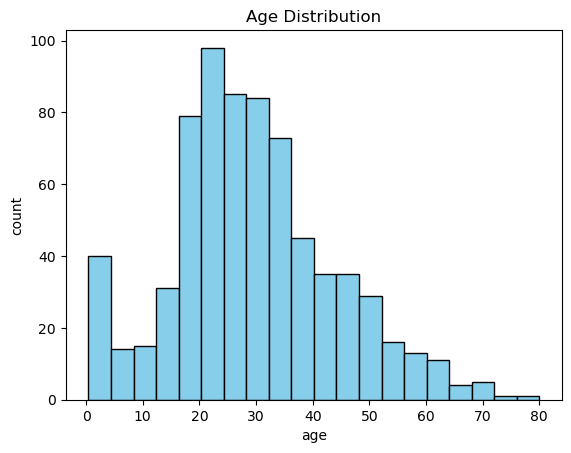

In [51]:
# 히스토그램: 나이 분포
plt.title('Age Distribution')
plt.hist(age, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('age')
plt.ylabel('count')
plt.show()

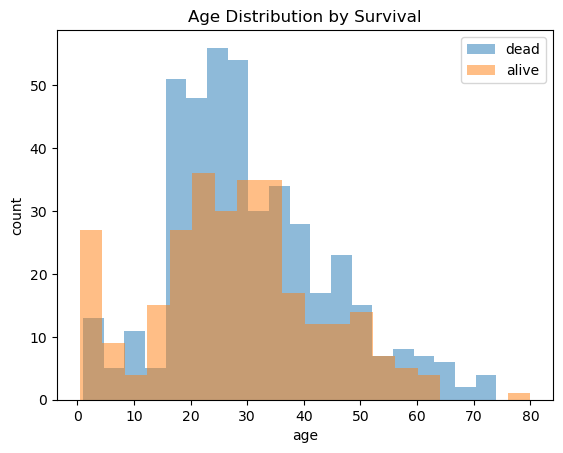

In [52]:
# 두 개의 히스토그램 겹쳐 그리기: 생존/사망 별 나이 분포
age_dead = df[df['survived'] == 0]['age'].dropna()
age_alive = df[df['survived'] == 1]['age'].dropna()

plt.title('Age Distribution by Survival')
plt.hist(age_dead, bins=20, alpha=0.5, label='dead')
plt.hist(age_alive, bins=20, alpha=0.5, label='alive')
plt.xlabel('age')
plt.ylabel('count')
plt.legend()
plt.show()

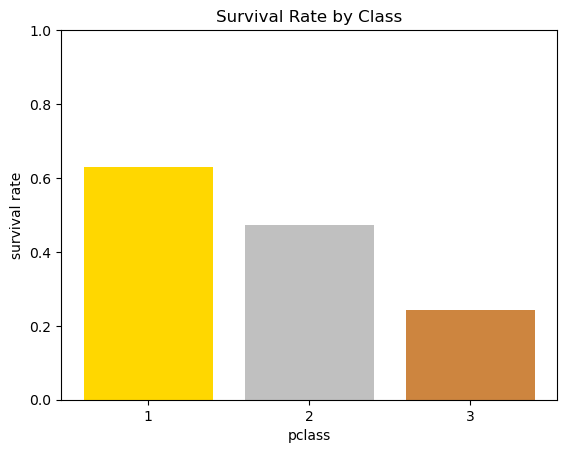

In [53]:
# 막대그래프: groupby 결과를 그대로 그리기
survival_by_class = df.groupby('pclass')['survived'].mean()

plt.title('Survival Rate by Class')
plt.bar(survival_by_class.index, survival_by_class.values, color=['gold', 'silver', 'peru'])
plt.xlabel('pclass')
plt.ylabel('survival rate')
plt.xticks([1, 2, 3])
plt.ylim(0, 1)
plt.show()

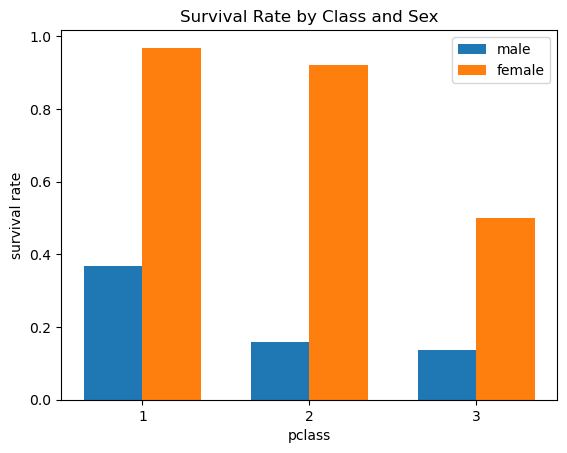

In [54]:
# 막대그래프 두 개 나란히 그리기: 등급별 x 성별 생존율
pivot = pd.pivot_table(df, index='pclass', columns='sex', values='survived', aggfunc='mean')

x = np.arange(len(pivot.index))   # [0, 1, 2]
width = 0.35

plt.title('Survival Rate by Class and Sex')
plt.bar(x - width/2, pivot['male'], width, label='male')
plt.bar(x + width/2, pivot['female'], width, label='female')
plt.xticks(x, pivot.index)
plt.xlabel('pclass')
plt.ylabel('survival rate')
plt.legend()
plt.show()

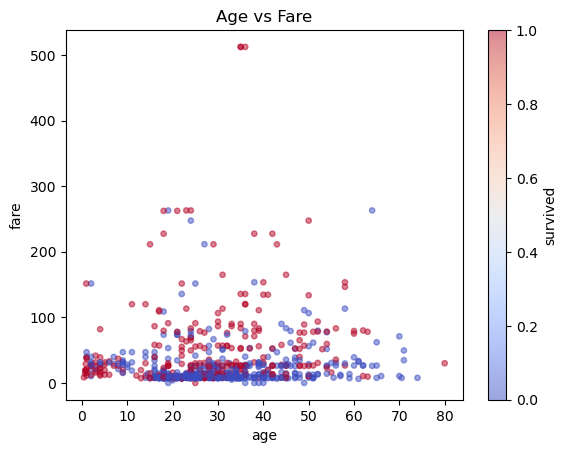

In [55]:
# 산점도: 나이 vs 운임, 색으로 생존 여부 표시
plt.title('Age vs Fare')
plt.scatter(df['age'], df['fare'], c=df['survived'], cmap='coolwarm', alpha=0.5, s=15)
plt.xlabel('age')
plt.ylabel('fare')
plt.colorbar(label='survived')
plt.show()

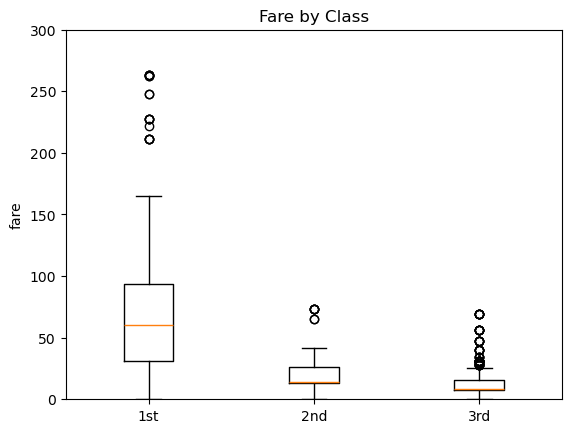

In [56]:
# 상자그림: 객실 등급별 운임 분포
fares_by_class = [df[df['pclass'] == c]['fare'] for c in [1, 2, 3]]

plt.title('Fare by Class')
plt.boxplot(fares_by_class)
plt.xticks([1, 2, 3], ['1st', '2nd', '3rd'])
plt.ylabel('fare')
plt.ylim(0, 300)   # 극단값 때문에 범위 제한
plt.show()

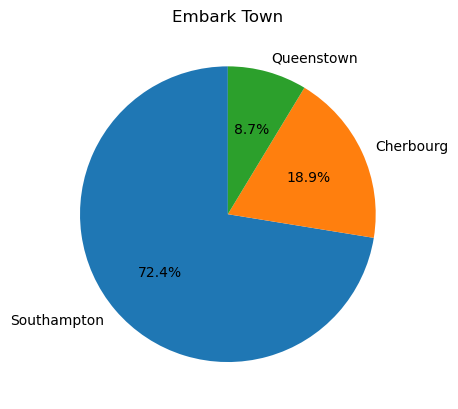

In [57]:
# 원그래프: 탑승 도시 비율
town_counts = df['embark_town'].value_counts()

plt.title('Embark Town')
plt.pie(town_counts.values, labels=town_counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

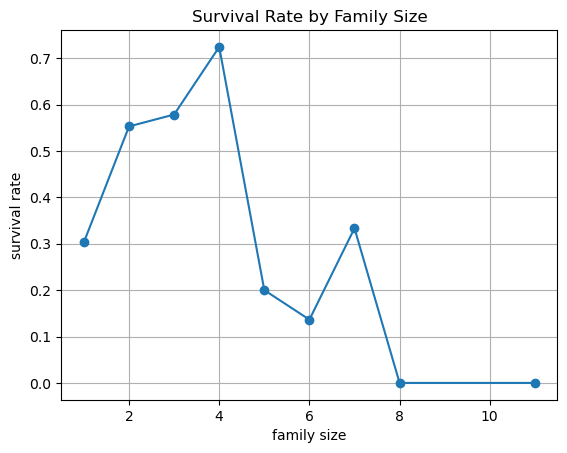

In [58]:
# 선그래프: 가족 수에 따른 생존율 변화
rate_by_family = df.groupby('family_size')['survived'].mean()

plt.title('Survival Rate by Family Size')
plt.plot(rate_by_family.index, rate_by_family.values, marker='o')
plt.xlabel('family size')
plt.ylabel('survival rate')
plt.grid(True)
plt.show()

#### 여러 그래프를 한 번에 그리기 (subplots)
* ```fig, axes = plt.subplots(행, 열, figsize=(가로, 세로))```
* 각 칸(```axes[i, j]```)에 ```ax.hist()```, ```ax.bar()``` 처럼 그림
* 제목/축 이름은 ```ax.set_title()```, ```ax.set_xlabel()``` 로 설정

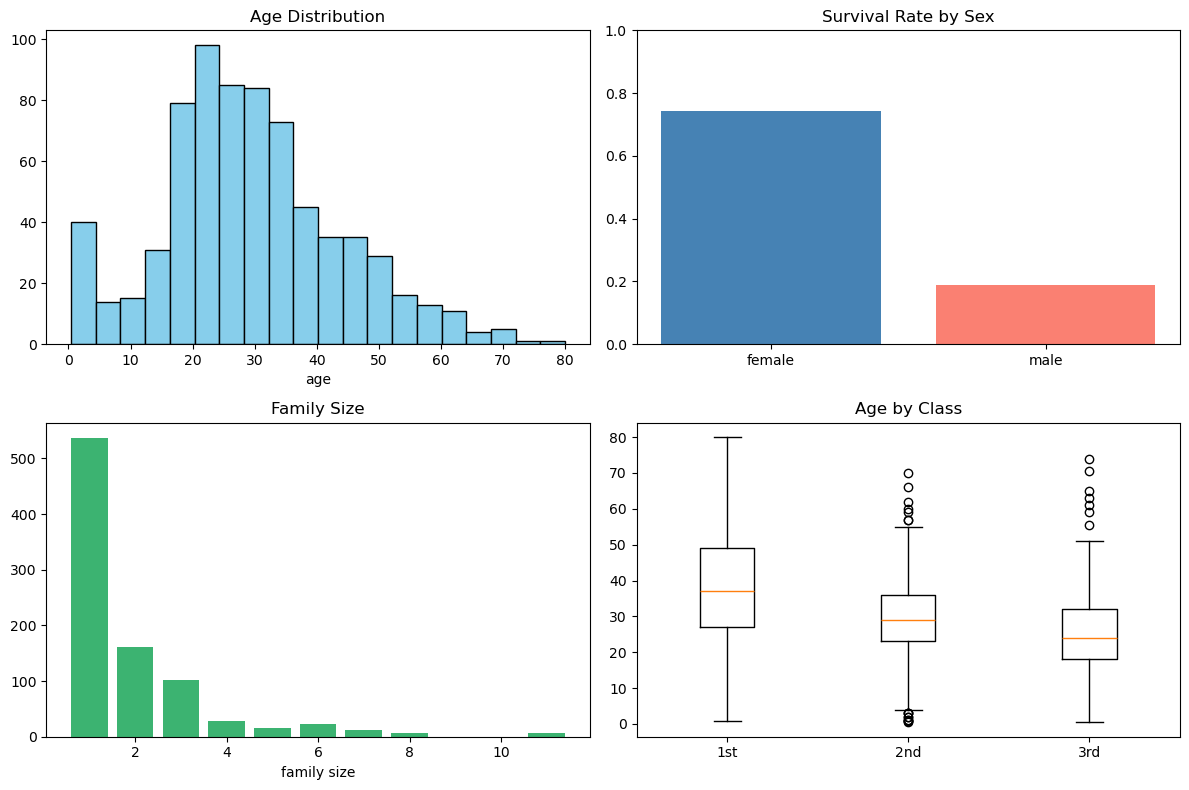

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# (0, 0) 나이 분포
axes[0, 0].hist(age, bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('age')

# (0, 1) 성별 생존율
rate_by_sex = df.groupby('sex')['survived'].mean()
axes[0, 1].bar(rate_by_sex.index, rate_by_sex.values, color=['steelblue', 'salmon'])
axes[0, 1].set_title('Survival Rate by Sex')
axes[0, 1].set_ylim(0, 1)

# (1, 0) 가족 수 분포
family_counts = df['family_size'].value_counts().sort_index()
axes[1, 0].bar(family_counts.index, family_counts.values, color='mediumseagreen')
axes[1, 0].set_title('Family Size')
axes[1, 0].set_xlabel('family size')

# (1, 1) 등급별 나이 상자그림 (비어 있는 값 제외)
ages_by_class = [df[df['pclass'] == c]['age'].dropna() for c in [1, 2, 3]]
axes[1, 1].boxplot(ages_by_class)
axes[1, 1].set_xticks([1, 2, 3], ['1st', '2nd', '3rd'])
axes[1, 1].set_title('Age by Class')

plt.tight_layout()   # 그래프 간 간격 자동 조정
plt.show()

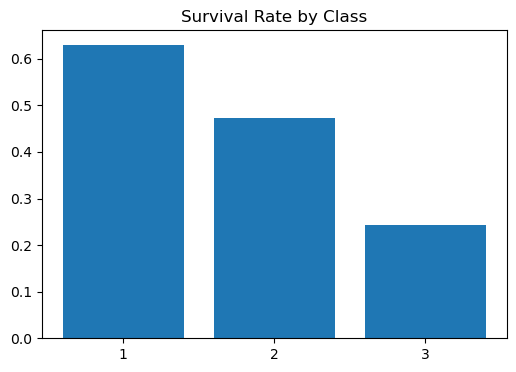

In [60]:
# 그림 파일로 저장하기
plt.figure(figsize=(6, 4))
plt.title('Survival Rate by Class')
plt.bar(survival_by_class.index, survival_by_class.values)
plt.xticks([1, 2, 3])
plt.savefig('survival_by_class.png', dpi=100, bbox_inches='tight')
plt.show()

In [61]:
## [연습 6-1] 운임(fare) 분포를 히스토그램으로 그리세요. (bins=30, 제목과 축 이름 포함)
#####################################
# Your code here
#####################################


## [연습 6-2] who(man / woman / child)별 생존율을 막대그래프로 그리세요.
#####################################
# Your code here
#####################################


## [연습 6-3] 1행 2열 subplots를 만들어 왼쪽에는 sibsp 분포, 오른쪽에는 parch 분포를 막대그래프로 그리세요.
##            (힌트: value_counts().sort_index())
#####################################
# Your code here
#####################################

### 7) 종합 연습 문제

지금까지 배운 내용을 조합해서 다음 질문에 답하세요. 숫자로 답한 뒤 그래프로도 확인해 봅니다.

In [62]:
## [문제 1] 객실 등급(pclass)별 평균 운임을 구하고, 막대그래프로 그리세요.
#####################################
# Your code here
#####################################

In [63]:
## [문제 2] 성별(sex)과 who 를 기준으로 pivot_table을 만들어 생존율을 출력하세요.
#####################################
# Your code here
#####################################

In [64]:
## [문제 3] 탑승 도시(embark_town)별 생존율을 구하고 막대그래프로 그리세요. 어느 도시의 생존율이 가장 높은지 확인하세요.
#####################################
# Your code here
#####################################

In [65]:
## [문제 4] 운임(fare)을 numpy 배열로 바꾸고 np.percentile로 상위 10% 경계값(90 백분위수)을 구한 뒤,
##          그 값보다 운임을 많이 낸 승객이 몇 명인지, 그들의 생존율은 얼마인지 출력하세요.
#####################################
# Your code here
#####################################

In [66]:
## [문제 5] 1행 3열 subplots를 만들어 1등석, 2등석, 3등석 승객의 나이 분포를 각각 히스토그램으로 그리세요.
##          세 그래프의 x축 범위를 (0, 80)으로 같게 맞추세요. (힌트: dropna(), ax.set_xlim)
#####################################
# Your code here
#####################################

In [67]:
## [문제 6] 정리된 데이터프레임 df를 'titanic_practice.csv' 파일로 저장하고 (인덱스 제외),
##          다시 읽어와서 shape가 같은지 확인하세요. (힌트: to_csv, read_csv)
#####################################
# Your code here
#####################################